# Loss Improvement Journey

For each config `(n, m, l, S)`, compare the BEST MSE achievable from each "era":

- **Old random-init**: seeds from the pre-violation-fix sweep
- **New warm-start** (`progv2_*`): seeds from `sweep_violation_fix.py`
- **Frontier push** (`frontier_*`): K=30 multi-source seeds

Shows how much each successive method improved over the prior. Sanity check that the recipe consistently helps and never regresses (additive store guarantees this).


In [1]:
import os, sys, json
sys.path.insert(0, '../code')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Pull per-seed data
rows = []
for path in sorted(Path('results_db/seeds').glob('*.json')):
    data = json.load(open(path))
    cfg = data['config']
    n, m, l, S = cfg['n'], cfg['m'], cfg['l'], cfg['S']
    for sd in data['seeds']:
        rid = sd.get('run_id', '')
        if 'progv2' in rid:
            era = 'warm_start'
        elif 'frontier' in rid:
            era = 'frontier'
        elif 'bootstrap_l1' in rid:
            era = 'bootstrap'
        else:
            era = 'random_init'
        rows.append(dict(n=n, m=m, l=l, S=S, era=era, mse_full=sd['mse_full']))

df_seeds = pd.DataFrame(rows)
print(f'{len(df_seeds)} seeds across {df_seeds["era"].nunique()} eras')
print(df_seeds.groupby('era').size())

# Best per (cfg, era)
df_best = df_seeds.groupby(['n', 'm', 'l', 'S', 'era'])['mse_full'].min().reset_index()
pivot = df_best.pivot_table(index=['n','m','l','S'], columns='era', values='mse_full')
print(f'\n{len(pivot)} unique configs')
print('Eras with data per config:')
print(pivot.notna().sum())


8989 seeds across 4 eras
era
bootstrap       264
frontier       1470
random_init    5743
warm_start     1512
dtype: int64

216 unique configs
Eras with data per config:
era
bootstrap       33
frontier        46
random_init    216
warm_start     112
dtype: int64


## Best MSE per era — warm_start vs random_init

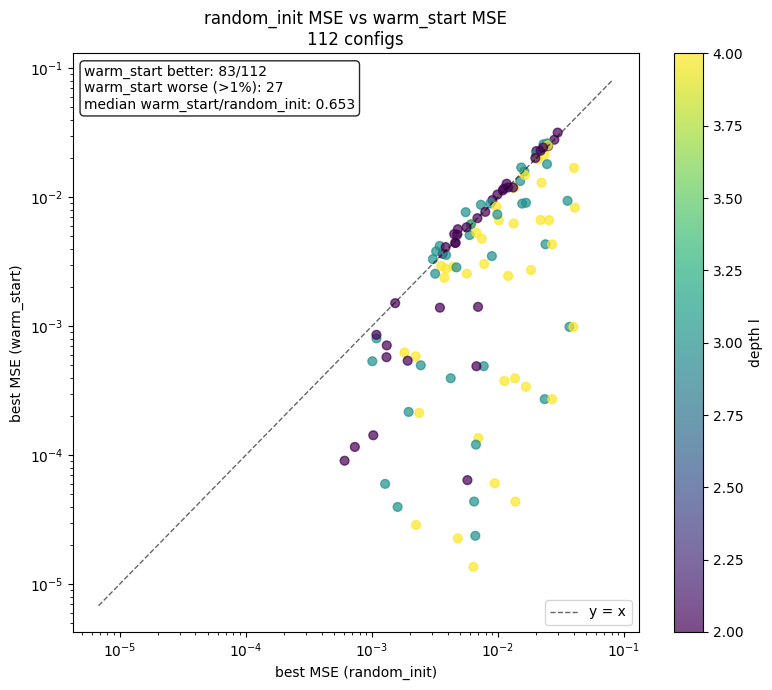

saved fig_improvement_random_vs_warm.png


In [2]:
def scatter_eras(pivot, x_era, y_era, title, save_path):
    both = pivot.dropna(subset=[x_era, y_era])
    if len(both) == 0:
        print(f'no overlap for {x_era} vs {y_era}')
        return
    x = both[x_era].values
    y = both[y_era].values
    
    fig, ax = plt.subplots(figsize=(8, 7))
    # Color by depth
    l_vals = both.index.get_level_values('l')
    sc = ax.scatter(x, y, c=l_vals, cmap='viridis', alpha=0.7, s=40)
    lo = min(x.min(), y.min()) * 0.5
    hi = max(x.max(), y.max()) * 2.0
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6, label='y = x')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'best MSE ({x_era})')
    ax.set_ylabel(f'best MSE ({y_era})')
    ax.set_title(title + f'\n{len(both)} configs')
    
    n_better = (y < x).sum()
    n_worse = (y > x * 1.01).sum()
    median_ratio = float(np.median(y / x))
    ax.text(0.02, 0.98, f'{y_era} better: {n_better}/{len(both)}\n{y_era} worse (>1%): {n_worse}\nmedian {y_era}/{x_era}: {median_ratio:.3f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.legend()
    plt.colorbar(sc, ax=ax, label='depth l')
    plt.tight_layout()
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()
    print('saved', save_path)


# random_init vs warm_start
if 'random_init' in pivot.columns and 'warm_start' in pivot.columns:
    scatter_eras(pivot, 'random_init', 'warm_start',
                 'random_init MSE vs warm_start MSE',
                 'fig_improvement_random_vs_warm.png')


## warm_start vs frontier_push

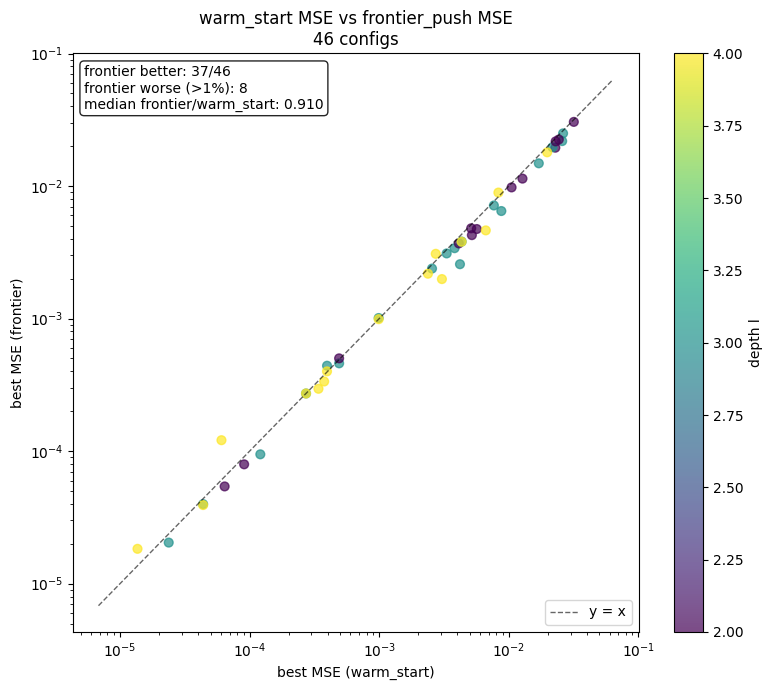

saved fig_improvement_warm_vs_frontier.png


In [3]:
if 'warm_start' in pivot.columns and 'frontier' in pivot.columns:
    scatter_eras(pivot, 'warm_start', 'frontier',
                 'warm_start MSE vs frontier_push MSE',
                 'fig_improvement_warm_vs_frontier.png')


## All-time best vs random_init baseline

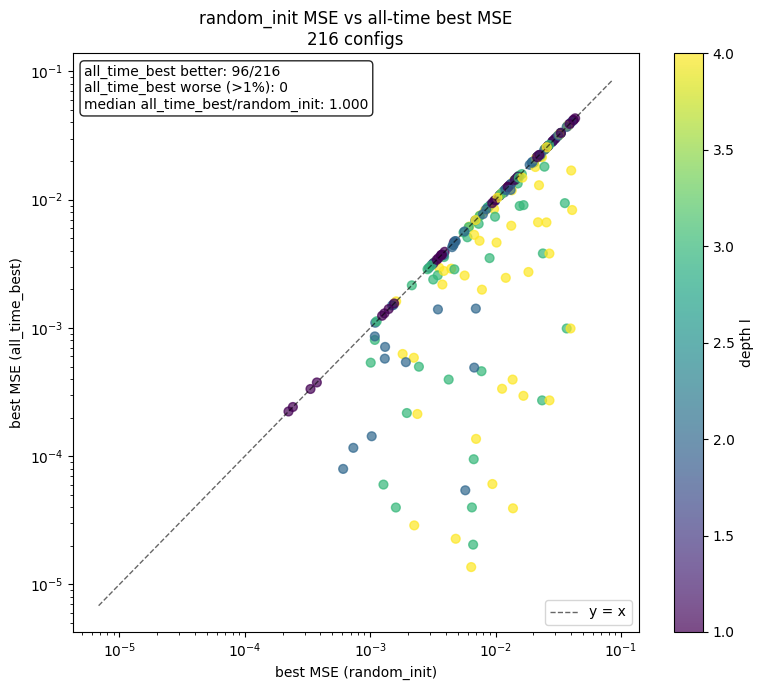

saved fig_improvement_random_vs_alltime.png

Median improvement vs random_init baseline:
  count    216.000000
mean       0.777472
std        0.353845
min        0.002133
25%        0.603472
50%        1.000000
75%        1.000000
max        1.000000
dtype: float64


In [4]:
# Compute all-time best per config (min across all eras)
pivot['all_time_best'] = pivot[[c for c in ['random_init', 'warm_start', 'frontier'] if c in pivot.columns]].min(axis=1)
if 'random_init' in pivot.columns:
    scatter_eras(pivot, 'random_init', 'all_time_best',
                 'random_init MSE vs all-time best MSE',
                 'fig_improvement_random_vs_alltime.png')

# Aggregate
print('\nMedian improvement vs random_init baseline:')
if 'random_init' in pivot.columns:
    valid = pivot.dropna(subset=['random_init', 'all_time_best'])
    print(f'  {(valid["all_time_best"] / valid["random_init"]).describe()}')
